# Groundwater quality risk in Bangladesh, 1998-99

## Setup

In [1]:
import csv
import glob
import os
import re
import warnings

os.environ.setdefault("PYTHONWARNINGS", "ignore::UserWarning:sklearn.utils.validation")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="X does not have valid feature names")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)

SEED = 42
np.random.seed(SEED)


def find_data_file():
    for root in ("/kaggle/input", "."):
        hits = glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
        named = [p for p in hits
                 if "nationalsurvey" in os.path.basename(p).lower().replace(" ", "")]
        if named:
            return named[0]
        if hits:
            return max(hits, key=os.path.getsize)
    raise FileNotFoundError("No CSV found. Set DATA_PATH manually.")


DATA_PATH = find_data_file()
print("Reading:", DATA_PATH)

Reading: /kaggle/input/datasets/mdnahidurrahmankh/bangladesh-national-groundwater-hydrochemical/NationalSurveyData.csv


## Loading the file

In [2]:
def is_number(text):
    try:
        float(text)
        return True
    except ValueError:
        return False


def find_header_row(path, scan=25):
    with open(path, newline="", encoding="utf-8", errors="replace") as fh:
        head = [row for _, row in zip(range(scan), csv.reader(fh))]

    best_row, best_score = 0, -1
    for i, row in enumerate(head):
        filled = [v.strip() for v in row if v.strip()]
        if len(filled) < 3:
            continue
        score = len(filled) + sum(not is_number(v) for v in filled)
        if score > best_score:
            best_row, best_score = i, score
    return best_row


def load_survey(path):
    header_row = find_header_row(path)
    df = pd.read_csv(path, skiprows=header_row, low_memory=False)
    df.columns = [str(c).strip() for c in df.columns]

    first = df.iloc[0].astype(str).str.lower()
    if first.str.contains(r"mg/l|ug/l|\u00b5g/l|ppm|ppb|metre|meter").sum() >= 3:
        df = df.iloc[1:]

    df = df.dropna(thresh=max(3, df.shape[1] // 4)).reset_index(drop=True)
    return df, header_row


raw, header_row = load_survey(DATA_PATH)
print(f"Header found on line {header_row + 1}; table is {raw.shape[0]} rows x {raw.shape[1]} columns")
print("Columns:", list(raw.columns))
raw.head()

Header found on line 5; table is 3534 rows x 34 columns
Columns: ['SAMPLE_ID', 'SAMPLE_FIELD_ID', 'SAMPLE_DATE', 'LAT_DEG', 'LONG_DEG', 'YEAR_CONSTRUCTION', 'WELL_TYPE', 'WELL_DEPTH', 'DIVISION', 'DISTRICT', 'THANA', 'UNION', 'MOUZA', 'GEOCODE', 'As', 'Al', 'B_', 'Ba', 'Ca', 'Co', 'Cr', 'Cu', 'Fe', 'K_', 'Li', 'Mg', 'Mn', 'Na', 'P_', 'Si', 'SO4', 'Sr', 'V_', 'Zn']


,SAMPLE_ID,SAMPLE_FIELD_ID,SAMPLE_DATE,LAT_DEG,LONG_DEG,YEAR_CONSTRUCTION,WELL_TYPE,WELL_DEPTH,DIVISION,DISTRICT,THANA,UNION,MOUZA,GEOCODE,As,Al,B_,Ba,Ca,Co,Cr,Cu,Fe,K_,Li,Mg,Mn,Na,P_,Si,SO4,Sr,V_,Zn
0,S98_00701,"RIP3491, BTS101",06/03/1998,22.8731,90.7844,1992.0,Shallow HP TW,10.7,Chittagong,Lakshmipur,Lakshmipur Sadar,Shakchar,Char Ramani Mohan,2.514385e+09,13,< 0.04,0.27,0.096,49.6,< 0.008,< 0.02,< 0.008,1.17,11.1,< 0.003,32.7,0.624,211,0.7,12.2,1.2,0.304,< 0.006,0.049
1,S98_00718,"RIP3492, BTS118",08/03/1998,23.0194,90.8786,1971.0,Shallow HP TW,12.2,Chittagong,Lakshmipur,Lakshmipur Sadar,Baksipur,Nandigram,2.514311e+09,256,< 0.04,0.04,0.01,56.9,< 0.008,< 0.02,< 0.008,1.74,6.9,< 0.003,29.9,0.447,7.9,1.2,13.9,< 0.2,0.246,< 0.006,0.031
2,S98_00724,"RIP3493, BTS124",10/03/1998,22.9650,90.9597,1995.0,Private HP TW,12.2,Chittagong,Lakshmipur,Lakshmipur Sadar,Uttar Joypur,Chandra Prabhabag,2.514395e+09,38,< 0.04,0.26,0.013,16.6,< 0.008,< 0.02,< 0.008,0.317,7.1,0.003,15.7,0.231,205,0.6,13.8,1.5,0.108,< 0.006,0.021
3,S98_00727,"RIP3498, BTS127",10/03/1998,22.9253,90.9744,1997.0,Private HP TW,262.1,Chittagong,Lakshmipur,Lakshmipur Sadar,Chandraganj,Ganipur,2.514320e+09,8,< 0.04,0.03,0.383,111,< 0.008,< 0.02,< 0.008,9.46,6.9,0.018,75.8,0.294,201,0.3,27.2,4.9,0.873,< 0.006,0.067
4,S98_00733,"RIP3494, BTS133",11/03/1998,22.8653,90.9372,1993.0,Private HP TW,7.9,Chittagong,Lakshmipur,Lakshmipur Sadar,Kushakhali,Madna,2.514356e+09,< 6,0.07,0.82,0.073,81,< 0.008,< 0.02,< 0.008,0.59,30.2,0.012,124,1.17,1090,0.5,10.3,265,0.797,0.009,0.054


## Naming the columns

In [3]:
def slug(name):
    name = re.sub(r"[\(\[].*?[\)\]]", " ", str(name))
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


FIELD_ALIASES = {
    "lat": ["latitude", "lat", "lat_deg", "y", "northing"],
    "lon": ["longitude", "lon", "long", "lng", "x", "easting"],
    "depth_m": ["well_depth", "depth", "depth_m", "screen_depth"],
    "install_year": ["year_of_installation", "year_installed", "installation_year", "year"],
    "well_type": ["well_type", "type_of_well", "tubewell_type", "pump_type"],
    "division": ["division"],
    "district": ["district", "zila"],
    "thana": ["thana", "upazila", "upazilla"],
    "sample_id": ["sample_id", "sample_no", "well_id", "id"],
}

CHEM_ALIASES = {
    "As": ["as", "as_total", "arsenic"],
    "Fe": ["fe", "iron"],
    "Mn": ["mn", "manganese"],
    "F": ["f", "fluoride"],
    "NO3_N": ["no3_n", "nitrate_n", "no3", "nitrate"],
    "Ca": ["ca", "calcium"], "Mg": ["mg", "magnesium"],
    "Na": ["na", "sodium"], "K": ["k", "potassium"],
    "Cl": ["cl", "chloride"], "SO4": ["so4", "sulphate", "sulfate"],
    "HCO3": ["hco3", "bicarbonate", "alkalinity"],
    "P": ["p", "phosphorus"], "Si": ["si", "silicon"],
    "Sr": ["sr"], "Ba": ["ba"], "Al": ["al"], "Cd": ["cd"], "U": ["u", "uranium"],
    "pH": ["ph"], "EC": ["ec", "conductivity", "sp_cond"],
}

MANUAL = {}

slugs = {c: slug(c) for c in raw.columns}


def match_column(aliases):
    for alias in aliases:
        for col, s in slugs.items():
            if s == alias:
                return col
    for alias in aliases:
        for col, s in slugs.items():
            if s.startswith(alias + "_") or s.endswith("_" + alias):
                return col
    return None


def header_unit(header):
    m = re.search(r"(\u00b5g/l|ug/l|mg/l|ppb|ppm|\u00b5s/cm|us/cm)", str(header).lower())
    if not m:
        return None
    return {"ppb": "ug/l", "ppm": "mg/l", "\u00b5g/l": "ug/l", "\u00b5s/cm": "us/cm"}.get(m.group(1), m.group(1))


rename, UNITS = {}, {}
for canonical, aliases in {**FIELD_ALIASES, **CHEM_ALIASES}.items():
    source = MANUAL.get(canonical) or match_column(aliases)
    if source is not None and source not in rename:
        rename[source] = canonical
        UNITS[canonical] = header_unit(source)

df = raw.rename(columns=rename)
CHEM_COLS = [c for c in CHEM_ALIASES if c in df.columns]
missing = [c for c in FIELD_ALIASES if c not in df.columns]

print(pd.DataFrame(
    [{"canonical": v, "original header": k, "unit": UNITS[v]} for k, v in rename.items()]
).to_string(index=False))
if missing:
    print("\nNot found in this file:", missing)

   canonical   original header unit
         lat           LAT_DEG None
         lon          LONG_DEG None
     depth_m        WELL_DEPTH None
install_year YEAR_CONSTRUCTION None
   well_type         WELL_TYPE None
    division          DIVISION None
    district          DISTRICT None
       thana             THANA None
   sample_id         SAMPLE_ID None
          As                As None
          Fe                Fe None
          Mn                Mn None
          Ca                Ca None
          Mg                Mg None
          Na                Na None
           K                K_ None
         SO4               SO4 None
           P                P_ None
          Si                Si None
          Sr                Sr None
          Ba                Ba None
          Al                Al None


## Cleaning

In [4]:
CENSOR_RE = r"^\s*([<>])\s*([0-9.]+)"


def parse_measurements(frame, cols):
    summary = []
    for c in cols:
        text = frame[c].astype(str).str.strip()
        marks = text.str.extract(CENSOR_RE)
        sign, limit = marks[0], pd.to_numeric(marks[1], errors="coerce")

        values = pd.to_numeric(text.where(sign.isna()), errors="coerce")
        below, above = sign.eq("<"), sign.eq(">")
        values[below] = limit[below] / 2
        values[above] = limit[above]
        frame[c] = values

        if below.any():
            frame[c + "_censored"] = below.astype(int)
            summary.append({"column": c, "n_below_limit": int(below.sum()),
                            "pct": round(100 * below.mean(), 1),
                            "limit": float(limit[below].median())})
    return pd.DataFrame(summary)


censoring = parse_measurements(df, CHEM_COLS)
print("Below detection limit:")
print(censoring.to_string(index=False) if len(censoring) else "  none")

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDropped {n_before - len(df)} duplicate rows, {len(df)} remain")

if "sample_id" in df.columns:
    print(f"Repeated sample IDs: {int(df['sample_id'].duplicated().sum())}")

if {"lat", "lon"} <= set(df.columns):
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    if df["lat"].abs().max() > 1000:
        off_map = df["lat"].isna() | df["lon"].isna()
    else:
        off_map = ~df["lat"].between(20.0, 27.0) | ~df["lon"].between(87.5, 93.0)
    print(f"Coordinates outside Bangladesh: {int(off_map.sum())} (set to missing)")
    df.loc[off_map, ["lat", "lon"]] = np.nan

if "depth_m" in df.columns:
    df["depth_m"] = pd.to_numeric(df["depth_m"], errors="coerce")
    bad_depth = (df["depth_m"] <= 0) | (df["depth_m"] > 500)
    print(f"Implausible well depths: {int(bad_depth.sum())} (set to missing)")
    df.loc[bad_depth, "depth_m"] = np.nan

if "install_year" in df.columns:
    df["install_year"] = pd.to_numeric(df["install_year"], errors="coerce")
    df.loc[~df["install_year"].between(1930, 1999), "install_year"] = np.nan

missing_report = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (100 * df.isna().mean()).round(1),
}).sort_values("pct_missing", ascending=False)
missing_report.head(15)

Below detection limit:
column  n_below_limit  pct  limit
    As           1105 31.3 0.5000
    Fe             14  0.4 0.0050
    Mn             25  0.7 0.0020
    Ca              1  0.0 0.1000
    Mg              1  0.0 0.0400
     K             19  0.5 0.5000
   SO4            844 23.9 0.2000
     P            996 28.2 0.1000
    Si              1  0.0 0.0300
    Sr              1  0.0 0.0004
    Ba              6  0.2 0.0020
    Al           1559 44.1 0.0400

Dropped 0 duplicate rows, 3534 remain
Repeated sample IDs: 0
Coordinates outside Bangladesh: 0 (set to missing)
Implausible well depths: 4 (set to missing)


,n_missing,pct_missing
install_year,42,1.2
MOUZA,9,0.3
well_type,7,0.2
UNION,7,0.2
Al,6,0.2
depth_m,4,0.1
Fe,4,0.1
Cu,4,0.1
Co,4,0.1
Cr,4,0.1


## What the data looks like

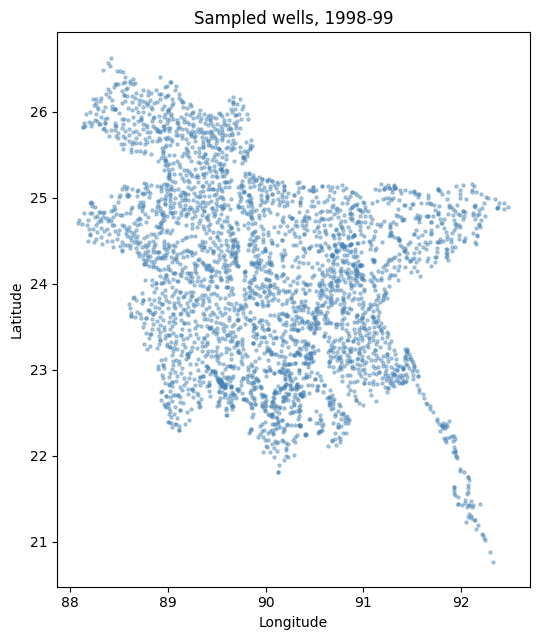

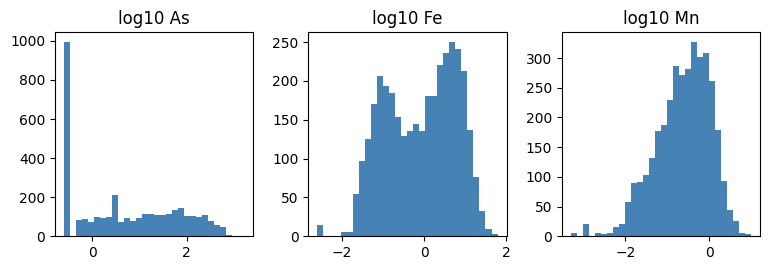

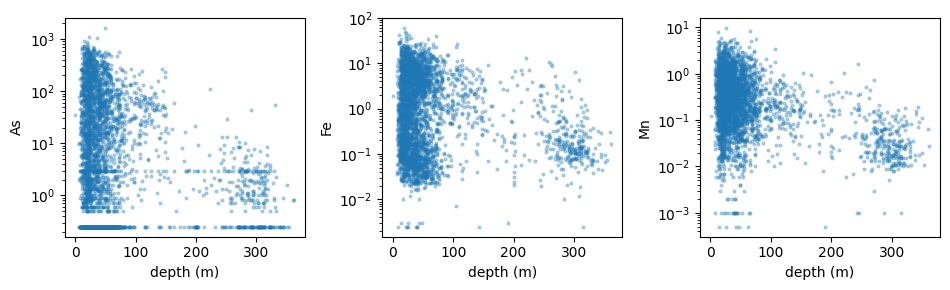

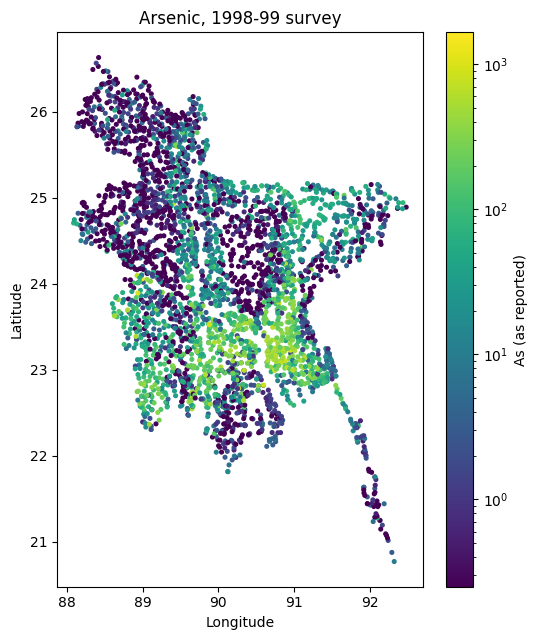

In [5]:
has_xy = {"lat", "lon"} <= set(df.columns) and df[["lat", "lon"]].notna().any().all()

if has_xy:
    fig, ax = plt.subplots(figsize=(5.5, 6.5))
    ax.scatter(df["lon"], df["lat"], s=5, alpha=0.4, color="steelblue")
    ax.set(title="Sampled wells, 1998-99", xlabel="Longitude", ylabel="Latitude")
    plt.tight_layout()
    plt.show()

show = [c for c in ["As", "Fe", "Mn", "F", "NO3_N", "pH"] if c in df.columns]
if show:
    fig, axes = plt.subplots(1, len(show), figsize=(2.6 * len(show), 2.8))
    for ax, c in zip(np.atleast_1d(axes), show):
        vals = df[c].dropna()
        positive = vals[vals > 0]
        if c != "pH" and len(positive) > 30 and vals.skew() > 1:
            ax.hist(np.log10(positive), bins=30, color="steelblue")
            ax.set_title(f"log10 {c}")
        else:
            ax.hist(vals, bins=30, color="steelblue")
            ax.set_title(c)
    plt.tight_layout()
    plt.show()

pairs = [c for c in ["As", "Fe", "Mn"] if c in df.columns]
if "depth_m" in df.columns and pairs:
    fig, axes = plt.subplots(1, len(pairs), figsize=(3.2 * len(pairs), 3))
    for ax, c in zip(np.atleast_1d(axes), pairs):
        ax.scatter(df["depth_m"], df[c], s=4, alpha=0.3)
        ax.set(xlabel="depth (m)", ylabel=c, yscale="log")
    plt.tight_layout()
    plt.show()

if has_xy and "As" in df.columns:
    from matplotlib.colors import LogNorm

    fig, ax = plt.subplots(figsize=(5.5, 6.5))
    positive = df["As"] > 0
    pts = ax.scatter(df.loc[positive, "lon"], df.loc[positive, "lat"],
                     c=df.loc[positive, "As"], cmap="viridis", s=7, norm=LogNorm())
    fig.colorbar(pts, ax=ax, label=f"As ({UNITS.get('As') or 'as reported'})")
    ax.set(title="Arsenic, 1998-99 survey", xlabel="Longitude", ylabel="Latitude")
    plt.tight_layout()
    plt.show()

## Targets and guideline values

In [6]:
GUIDELINES = {
    "As": (50.0, "ug/l"),
    "Mn": (0.1, "mg/l"),
    "Fe": (1.0, "mg/l"),
    "F": (1.0, "mg/l"),
    "NO3_N": (10.0, "mg/l"),
}
WHO_REFERENCE = {
    "As": (10.0, "ug/l"),
    "Mn": (None, None),
    "Fe": (None, None),
    "F": (1.5, "mg/l"),
    "NO3_N": (11.3, "mg/l"),
}
MIN_VALID = 200
MAX_CENSORED_PCT = 60
MIN_EXCEEDANCES = 25


def unit_factor(have, want):
    if have is None or have == want:
        return 1.0
    return {("mg/l", "ug/l"): 1000.0, ("ug/l", "mg/l"): 0.001}.get((have, want), 1.0)


rows = []
for c, (limit, unit) in GUIDELINES.items():
    if c not in df.columns or not pd.api.types.is_numeric_dtype(df[c]):
        continue
    factor = unit_factor(UNITS.get(c), unit)
    converted = df[c] * factor
    exceeds = np.where(converted.isna(), np.nan, (converted > limit).astype(float))
    censor_col = f"{c}_censored"
    who_limit, who_unit = WHO_REFERENCE.get(c, (None, None))
    rows.append({
        "contaminant": c,
        "n_valid": int(converted.notna().sum()),
        "pct_censored": round(100 * df[censor_col].mean(), 1) if censor_col in df else 0.0,
        "unit_in_file": UNITS.get(c) or f"assumed {unit}",
        "bangladesh_guideline": f"{limit} {unit}",
        "who_reference": f"{who_limit} {who_unit}" if who_limit is not None else "no current guideline",
        "n_exceed": int(np.nansum(exceeds)),
        "exceedance_rate": round(float(np.nanmean(exceeds)), 3),
    })
    df[f"{c}_exceeds"] = exceeds

target_table = pd.DataFrame(rows).sort_values("n_exceed", ascending=False)
display(target_table)

eligible = target_table[
    (target_table.n_valid >= MIN_VALID)
    & (target_table.pct_censored <= MAX_CENSORED_PCT)
    & (target_table.n_exceed >= MIN_EXCEEDANCES)
]
if eligible.empty:
    raise ValueError("No contaminant is usable as a target. Check the unit column above first.")

TARGET = "As" if "As" in set(eligible.contaminant) else eligible.iloc[0]["contaminant"]
TARGET_LIMIT, TARGET_UNIT = GUIDELINES[TARGET]
df[TARGET] = df[TARGET] * unit_factor(UNITS.get(TARGET), TARGET_UNIT)
UNITS[TARGET] = TARGET_UNIT

CLS_TARGET = f"{TARGET}_exceeds"
REG_TARGET = f"{TARGET}_log10"
df[REG_TARGET] = np.log10(df[TARGET].clip(lower=0.01))

print(f"\nTarget: {TARGET} (Bangladesh guideline {TARGET_LIMIT} {TARGET_UNIT})")
print(f"Exceedance rate: {df[CLS_TARGET].mean():.1%} of {int(df[CLS_TARGET].notna().sum())} measured wells")
print(f"Eligible for the multi-contaminant score: {list(eligible.contaminant)}")

,contaminant,n_valid,pct_censored,unit_in_file,bangladesh_guideline,who_reference,n_exceed,exceedance_rate
1,Mn,3530,0.7,assumed mg/l,0.1 mg/l,no current guideline,2596,0.735
2,Fe,3530,0.4,assumed mg/l,1.0 mg/l,no current guideline,1806,0.512
0,As,3534,31.3,assumed ug/l,50.0 ug/l,10.0 ug/l,881,0.249



Target: As (Bangladesh guideline 50.0 ug/l)
Exceedance rate: 24.9% of 3534 measured wells
Eligible for the multi-contaminant score: ['Mn', 'Fe', 'As']


## Features and prediction scenarios, made explicit

In [12]:
WELL_FEATURES = [c for c in ["depth_m", "install_year", "well_type"] if c in df.columns]
PLACE_FEATURES = [c for c in ["division", "district"] if c in df.columns]
CHEM_FEATURES = [c for c in CHEM_COLS
                 if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]

FEATURES_A = CHEM_FEATURES + WELL_FEATURES
FEATURES_B = [c for c in ["lat", "lon"] if c in df.columns] + WELL_FEATURES + PLACE_FEATURES

for c in WELL_FEATURES + PLACE_FEATURES:
    if df[c].dtype == object:
        df[c] = df[c].astype("category")

print("Scenario A (explanatory - needs a water sample):", FEATURES_A)
print("Scenario B (predictive - usable before sampling):", FEATURES_B)


def build_matrix(features, target, frame):
    use = [c for c in features if c in frame.columns]
    keep = frame[target].notna()
    X = frame.loc[keep, use].copy()
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype("category")
    y = frame.loc[keep, target]
    if y.dropna().isin([0, 1]).all():
        y = y.astype(int)
    return X, y, frame.loc[keep]

Scenario A (explanatory - needs a water sample): ['Fe', 'Mn', 'Ca', 'Mg', 'Na', 'K', 'SO4', 'P', 'Si', 'Sr', 'Ba', 'Al', 'depth_m', 'install_year', 'well_type']
Scenario B (predictive - usable before sampling): ['lat', 'lon', 'depth_m', 'install_year', 'well_type', 'division', 'district']


## Spatial blocks

In [13]:
def assign_blocks(frame, block_size, degrees):
    located = frame[["lat", "lon"]].notna().all(axis=1)
    blocks = pd.Series(pd.NA, index=frame.index, dtype=object)
    blocks.loc[located] = (
        np.floor(frame.loc[located, "lon"] / block_size).astype(int).astype(str)
        + "_" + np.floor(frame.loc[located, "lat"] / block_size).astype(int).astype(str)
    )
    return blocks


if has_xy:
    degrees = df["lon"].abs().max() < 200
    BLOCK = 0.25 if degrees else 25_000
    df["grid_block"] = assign_blocks(df, BLOCK, degrees)
    block_sizes = df["grid_block"].value_counts()
    print(f"{len(block_sizes)} blocks at {BLOCK} {'deg' if degrees else 'm'}; "
          f"median {block_sizes.median():.0f} wells per block, largest {block_sizes.max()}")
else:
    degrees = True
    df["grid_block"] = pd.NA
    print("No usable coordinates - spatial validation and mapping will be skipped.")

model_df = df[df["grid_block"].notna()].copy()
print(f"Modelling set: {len(model_df)} wells ({len(df) - len(model_df)} dropped for missing coordinates)")

209 blocks at 0.25 deg; median 17 wells per block, largest 49
Modelling set: 3534 wells (0 dropped for missing coordinates)


## Splitting schemes, including repeated spatial validation

In [15]:
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit, KFold,
                                     StratifiedKFold, cross_val_predict,
                                     train_test_split)

TEST_SIZE = 0.20
N_SPLITS = 5
N_REPEATS = 8


def random_split(X, y, seed=SEED):
    strat = y if y.nunique() <= 10 else None
    train, test = train_test_split(X.index, test_size=TEST_SIZE, random_state=seed, stratify=strat)
    return pd.Index(train), pd.Index(test)


def spatial_split(frame, seed=SEED):
    blocks = frame["grid_block"].unique()
    rng = np.random.RandomState(seed)
    rng.shuffle(blocks)
    sizes = frame["grid_block"].value_counts()
    quota, taken, held_out = TEST_SIZE * len(frame), 0, []
    for b in blocks:
        if taken >= quota:
            break
        held_out.append(b)
        taken += sizes[b]
    test = frame.index[frame["grid_block"].isin(held_out)]
    return frame.index.difference(test), test


def repeated_spatial_splits(X, frame, n_repeats=N_REPEATS, test_size=TEST_SIZE, seed=SEED):
    groups = frame.loc[X.index, "grid_block"]
    gss = GroupShuffleSplit(n_splits=n_repeats, test_size=test_size, random_state=seed)
    return list(gss.split(X, groups=groups))


def cv_random(X, y):
    if y.nunique() <= 10:
        return list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(X, y))
    return list(KFold(N_SPLITS, shuffle=True, random_state=SEED).split(X))


def cv_spatial(X, frame, y=None):
    groups = frame.loc[X.index, "grid_block"]
    if groups.nunique() < N_SPLITS:
        print("Too few blocks for GroupKFold - falling back to a random CV")
        return cv_random(X, y if y is not None else pd.Series(0, index=X.index))
    return list(GroupKFold(N_SPLITS).split(X, groups=groups))

## Models

In [16]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import brier_score_loss
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_pipeline(model, X):
    num = X.select_dtypes(include=[np.number]).columns.tolist()
    cat = [c for c in X.columns if c not in num]
    steps = []
    if num:
        steps.append(("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                                       ("scale", StandardScaler())]), num))
    if cat:
        steps.append(("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                       ("ohe", OneHotEncoder(handle_unknown="ignore",
                                                             sparse_output=False))]), cat))
    return Pipeline([("prep", ColumnTransformer(steps)), ("model", model)])


MODELS = {
    "RandomForest": {
        "clf": RandomForestClassifier, "reg": RandomForestRegressor,
        "kwargs": {"random_state": SEED, "n_jobs": -1},
        "grid": {"model__n_estimators": [200, 400],
                 "model__max_depth": [None, 8, 16],
                 "model__min_samples_leaf": [1, 2, 4]},
    },
}

try:
    from xgboost import XGBClassifier, XGBRegressor
    MODELS["XGBoost"] = {
        "clf": XGBClassifier, "reg": XGBRegressor,
        "kwargs": {"random_state": SEED, "verbosity": 0},
        "grid": {"model__n_estimators": [200, 400],
                 "model__max_depth": [3, 5, 7],
                 "model__learning_rate": [0.03, 0.06, 0.1],
                 "model__subsample": [0.7, 0.9, 1.0]},
    }
except ImportError:
    print("xgboost not installed - skipped")

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    MODELS["LightGBM"] = {
        "clf": LGBMClassifier, "reg": LGBMRegressor,
        "kwargs": {"random_state": SEED, "verbose": -1},
        "grid": {"model__n_estimators": [200, 400],
                 "model__num_leaves": [15, 31, 63],
                 "model__learning_rate": [0.03, 0.06, 0.1]},
    }
except ImportError:
    print("lightgbm not installed - skipped")

try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    MODELS["CatBoost"] = {
        "clf": CatBoostClassifier, "reg": CatBoostRegressor,
        "kwargs": {"random_seed": SEED, "verbose": False},
        "grid": {"model__depth": [4, 6, 8],
                 "model__learning_rate": [0.03, 0.06, 0.1],
                 "model__iterations": [300, 500]},
    }
except ImportError:
    print("catboost not installed - skipped")

MODELS["MLP"] = {
    "clf": lambda **kw: MLPClassifier(hidden_layer_sizes=(32,), max_iter=500,
                                      early_stopping=True, random_state=SEED),
    "reg": lambda **kw: MLPRegressor(hidden_layer_sizes=(32,), max_iter=500,
                                     early_stopping=True, random_state=SEED),
    "kwargs": {}, "grid": None,
}

print("Models this run:", list(MODELS))

Models this run: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP']


## Tuning

In [17]:
from sklearn.model_selection import RandomizedSearchCV

N_ITER = 12


def fit_model(name, task, X, y, cv):
    spec = MODELS[name]
    estimator = spec["clf"] if task == "clf" else spec["reg"]
    pipe = make_pipeline(estimator(**spec["kwargs"]), X)
    if not spec["grid"]:
        return pipe.fit(X, y)
    search = RandomizedSearchCV(
        pipe, spec["grid"], n_iter=N_ITER,
        scoring="roc_auc" if task == "clf" else "neg_root_mean_squared_error",
        cv=cv, random_state=SEED, n_jobs=-1, refit=True,
    )
    search.fit(X, y)
    best = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    print(f"  {name}: {best}")
    return search.best_estimator_

## Metrics

In [18]:
from scipy.stats import spearmanr
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             mean_absolute_error, precision_score, r2_score,
                             recall_score, roc_auc_score)

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred) ** 0.5


def screening_threshold(proba, prevalence):
    return float(np.quantile(proba, 1 - prevalence))


def score_classification(y_true, proba, prevalence):
    pred = (proba >= screening_threshold(proba, prevalence)).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    both_classes = len(np.unique(y_true)) > 1
    return {
        "ROC_AUC": roc_auc_score(y_true, proba) if both_classes else np.nan,
        "PR_AUC": average_precision_score(y_true, proba) if both_classes else np.nan,
        "F1": f1_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) else np.nan,
    }


def score_regression(y_true, pred):
    both_finite = np.isfinite(y_true).all() and np.isfinite(pred).all()
    spearman = spearmanr(y_true, pred).statistic if (both_finite and np.std(pred) > 0) else np.nan
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "RMSE": root_mean_squared_error(y_true, pred),
        "R2": r2_score(y_true, pred),
        "Spearman": spearman,
    }

## The main experiment: random split vs spatial split (Scenario A, explanatory)


=== random split (reference partition): 2827 train / 707 test, 24.9% exceed in test ===
  RandomForest: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': None}
  XGBoost: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  LightGBM: {'num_leaves': 63, 'n_estimators': 400, 'learning_rate': 0.1}
  CatBoost: {'learning_rate': 0.03, 'iterations': 500, 'depth': 8}

=== spatial split (reference partition): 2817 train / 717 test, 25.9% exceed in test ===
  RandomForest: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': None}
  XGBoost: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03}
  LightGBM: {'num_leaves': 15, 'n_estimators': 400, 'learning_rate': 0.03}
  CatBoost: {'learning_rate': 0.03, 'iterations': 500, 'depth': 6}

Single reference partition (used only to pick hyperparameters):


,split,model,ROC_AUC,PR_AUC,F1,Precision,Recall,Specificity
0,random,Dummy,0.500,0.249,0.399,0.249,1.000,0.000
1,random,LogisticRegression,0.890,0.732,0.708,0.706,0.710,0.902
2,random,RandomForest,0.944,0.846,0.754,0.751,0.756,0.917
3,random,XGBoost,0.948,0.865,0.776,0.774,0.778,0.925
4,random,LightGBM,0.953,0.870,0.810,0.808,0.812,0.936
5,random,CatBoost,0.955,0.873,0.793,0.791,0.795,0.930
6,random,MLP,0.903,0.752,0.708,0.706,0.710,0.902
7,spatial,Dummy,0.500,0.259,0.412,0.259,1.000,0.000
8,spatial,LogisticRegression,0.874,0.719,0.672,0.689,0.656,0.896
9,spatial,RandomForest,0.947,0.868,0.799,0.819,0.780,0.940



Repeated spatial holdout ROC-AUC across 8 independent block partitions (this is the number to quote):


,mean,std,min,max
model,,,,
CatBoost,0.953,0.009,0.935,0.962
XGBoost,0.953,0.008,0.941,0.964
LightGBM,0.950,0.009,0.934,0.961
RandomForest,0.950,0.009,0.933,0.959
MLP,0.893,0.039,0.802,0.923


split,random,spatial,spatial_repeated_mean,spatial_repeated_std,optimism
model,,,,,
CatBoost,0.955,0.953,0.953,0.009,0.002
XGBoost,0.948,0.950,0.953,0.008,-0.005
LightGBM,0.953,0.952,0.950,0.009,0.003
RandomForest,0.944,0.947,0.950,0.009,-0.006
MLP,0.903,0.906,0.893,0.039,0.010
Dummy,0.500,0.500,NaN,NaN,NaN
LogisticRegression,0.890,0.874,NaN,NaN,NaN


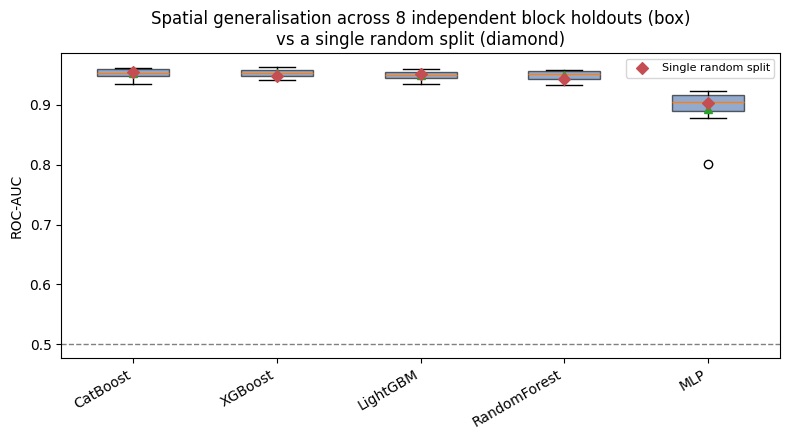


Best by mean repeated-spatial ROC-AUC: CatBoost (0.953 +/- 0.009, vs 0.955 on a single random split)
Mean optimism (random split minus repeated-spatial mean): 0.001 AUC


In [19]:
X_all, y_all, frame_all = build_matrix(FEATURES_A, CLS_TARGET, model_df)

train_idx, test_idx = random_split(X_all, y_all)
sp_train_idx, sp_test_idx = spatial_split(frame_all)
splits = {
    "random": (train_idx, test_idx, cv_random),
    "spatial": (sp_train_idx, sp_test_idx, cv_spatial),
}

results, fitted = [], {}
for scheme, (tr, te, cv_fn) in splits.items():
    X_tr, X_te = X_all.loc[tr], X_all.loc[te]
    y_tr, y_te = y_all.loc[tr], y_all.loc[te]
    cv = cv_fn(X_tr, y_tr) if scheme == "random" else cv_fn(X_tr, frame_all)
    print(f"\n=== {scheme} split (reference partition): {len(X_tr)} train / {len(X_te)} test, "
          f"{y_te.mean():.1%} exceed in test ===")

    for label, model in [("Dummy", DummyClassifier(strategy="prior")),
                         ("LogisticRegression", LogisticRegression(max_iter=2000, random_state=SEED))]:
        pipe = make_pipeline(model, X_tr).fit(X_tr, y_tr)
        results.append({"split": scheme, "model": label,
                        **score_classification(y_te, pipe.predict_proba(X_te)[:, 1], y_tr.mean())})

    for name in MODELS:
        model = fit_model(name, "clf", X_tr, y_tr, cv)
        results.append({"split": scheme, "model": name,
                        **score_classification(y_te, model.predict_proba(X_te)[:, 1], y_tr.mean())})
        fitted[(scheme, name)] = model

results_df = pd.DataFrame(results)
print("\nSingle reference partition (used only to pick hyperparameters):")
display(results_df.round(3))

repeat_rows = []
for pos, (tr_pos, te_pos) in enumerate(repeated_spatial_splits(X_all, frame_all)):
    X_tr, X_te = X_all.iloc[tr_pos], X_all.iloc[te_pos]
    y_tr, y_te = y_all.iloc[tr_pos], y_all.iloc[te_pos]
    for name in MODELS:
        model = clone(fitted[("spatial", name)])
        model.fit(X_tr, y_tr)
        repeat_rows.append({"repeat": pos, "model": name,
                            **score_classification(y_te, model.predict_proba(X_te)[:, 1], y_tr.mean())})

repeat_df = pd.DataFrame(repeat_rows)
spatial_summary = (repeat_df.groupby("model")["ROC_AUC"]
                   .agg(["mean", "std", "min", "max"]).round(3)
                   .sort_values("mean", ascending=False))
print(f"\nRepeated spatial holdout ROC-AUC across {N_REPEATS} independent block partitions "
      "(this is the number to quote):")
display(spatial_summary)

comparison = (results_df.pivot(index="model", columns="split", values="ROC_AUC"))
comparison["spatial_repeated_mean"] = spatial_summary["mean"]
comparison["spatial_repeated_std"] = spatial_summary["std"]
comparison["optimism"] = comparison["random"] - comparison["spatial_repeated_mean"]
comparison = comparison.sort_values("spatial_repeated_mean", ascending=False)
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
model_order = [m for m in comparison.index if m in MODELS]
data_for_box = [repeat_df.loc[repeat_df.model == m, "ROC_AUC"].values for m in model_order]
bp = ax.boxplot(data_for_box, positions=np.arange(len(model_order)), widths=0.5,
                patch_artist=True, showmeans=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#4c72b0")
    patch.set_alpha(0.6)
ax.scatter(np.arange(len(model_order)),
          [comparison.loc[m, "random"] for m in model_order],
          color="#c44e52", marker="D", zorder=5, label="Single random split")
ax.axhline(0.5, color="grey", ls="--", lw=1)
ax.set_xticks(np.arange(len(model_order)), model_order, rotation=30, ha="right")
ax.set(ylabel="ROC-AUC",
       title=f"Spatial generalisation across {N_REPEATS} independent block holdouts (box)\n"
             "vs a single random split (diamond)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

BEST_NAME = spatial_summary.index[0]
BEST_MODEL = fitted[("spatial", BEST_NAME)]
train_idx, test_idx = sp_train_idx, sp_test_idx
X_train, X_test = X_all.loc[train_idx], X_all.loc[test_idx]
y_train, y_test = y_all.loc[train_idx], y_all.loc[test_idx]
print(f"\nBest by mean repeated-spatial ROC-AUC: {BEST_NAME} "
      f"({spatial_summary.loc[BEST_NAME, 'mean']:.3f} +/- {spatial_summary.loc[BEST_NAME, 'std']:.3f}, "
      f"vs {comparison.loc[BEST_NAME, 'random']:.3f} on a single random split)")
real_models = comparison.index.intersection(list(MODELS))
print(f"Mean optimism (random split minus repeated-spatial mean): "
      f"{comparison.loc[real_models, 'optimism'].mean():.3f} AUC")

### Is this sensitive to the block size itself?

In [20]:
BLOCK_SIZE_FACTORS = [0.5, 1.0, 2.0]

block_size_rows = []
for factor in BLOCK_SIZE_FACTORS:
    alt_size = BLOCK * factor
    alt_blocks = assign_blocks(frame_all, alt_size, degrees)
    tmp = frame_all.copy()
    tmp["grid_block"] = alt_blocks
    tmp = tmp[tmp["grid_block"].notna()]
    Xc = X_all.loc[X_all.index.intersection(tmp.index)]
    yc = y_all.loc[Xc.index]
    tmp = tmp.loc[Xc.index]

    aucs = []
    for tr_pos, te_pos in repeated_spatial_splits(Xc, tmp, n_repeats=5, seed=SEED + 100):
        X_tr, X_te = Xc.iloc[tr_pos], Xc.iloc[te_pos]
        y_tr, y_te = yc.iloc[tr_pos], yc.iloc[te_pos]
        m = clone(BEST_MODEL)
        m.fit(X_tr, y_tr)
        if y_te.nunique() > 1:
            aucs.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))

    block_size_rows.append({
        "block_size_factor": factor, "approx_block_size": round(alt_size, 3),
        "n_blocks": tmp["grid_block"].nunique(),
        "mean_AUC": round(float(np.mean(aucs)), 3) if aucs else np.nan,
        "std_AUC": round(float(np.std(aucs)), 3) if aucs else np.nan,
    })

display(pd.DataFrame(block_size_rows))
print(f"For reference, the chosen block size gave a repeated-spatial mean AUC of "
      f"{spatial_summary.loc[BEST_NAME, 'mean']:.3f} for {BEST_NAME}.")
print("A stable AUC across block sizes means the headline spatial number is not an artefact of\n"
      "the ~25 km grid choice; a large swing would mean it is.")

,block_size_factor,approx_block_size,n_blocks,mean_AUC,std_AUC
0,0.5,0.125,700,0.950,0.010
1,1.0,0.250,209,0.950,0.008
2,2.0,0.500,68,0.945,0.010


For reference, the chosen block size gave a repeated-spatial mean AUC of 0.953 for CatBoost.
A stable AUC across block sizes means the headline spatial number is not an artefact of
the ~25 km grid choice; a large swing would mean it is.


## Regression on log concentration (Scenario A, explanatory)

In [21]:
Xr, yr, frame_r = build_matrix(FEATURES_A, REG_TARGET, model_df)
r_train, r_test = spatial_split(frame_r)
Xr_train, Xr_test = Xr.loc[r_train], Xr.loc[r_test]
yr_train, yr_test = yr.loc[r_train], yr.loc[r_test]
cv_r = cv_spatial(Xr_train, frame_r)

reg_results, fitted_reg = [], {}
for label, model in [("Median", DummyRegressor(strategy="median")),
                     ("Ridge", Ridge(random_state=SEED))]:
    pipe = make_pipeline(model, Xr_train).fit(Xr_train, yr_train)
    reg_results.append({"model": label, **score_regression(yr_test, pipe.predict(Xr_test))})

for name in MODELS:
    model = fit_model(name, "reg", Xr_train, yr_train, cv_r)
    reg_results.append({"model": name, **score_regression(yr_test, model.predict(Xr_test))})
    fitted_reg[name] = model

reg_df = pd.DataFrame(reg_results).sort_values("RMSE")
print("Single reference spatial holdout (used to pick hyperparameters):")
display(reg_df.round(3))

reg_repeat_rows = []
for pos, (tr_pos, te_pos) in enumerate(repeated_spatial_splits(Xr, frame_r)):
    X_tr, X_te = Xr.iloc[tr_pos], Xr.iloc[te_pos]
    y_tr, y_te = yr.iloc[tr_pos], yr.iloc[te_pos]
    for name in MODELS:
        model = clone(fitted_reg[name])
        model.fit(X_tr, y_tr)
        reg_repeat_rows.append({"repeat": pos, "model": name, **score_regression(y_te, model.predict(X_te))})

reg_repeat_df = pd.DataFrame(reg_repeat_rows)
reg_summary = (reg_repeat_df.groupby("model")[["RMSE", "Spearman"]]
              .agg(["mean", "std"]).round(3))
print(f"\nRepeated spatial holdout across {N_REPEATS} independent block partitions "
      "(this is the number to quote):")
display(reg_summary)

BEST_REG_NAME = reg_summary[("RMSE", "mean")].idxmin()
BEST_REG_MODEL = fitted_reg[BEST_REG_NAME]
print(f"\nBest regression model by mean repeated-spatial RMSE: {BEST_REG_NAME} "
      f"({reg_summary.loc[BEST_REG_NAME, ('RMSE', 'mean')]:.3f} "
      f"+/- {reg_summary.loc[BEST_REG_NAME, ('RMSE', 'std')]:.3f} log10 units)")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  RandomForest: {'n_estimators': 400, 'min_samples_leaf': 2, 'max_depth': 16}
  XGBoost: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  LightGBM: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.03}
  CatBoost: {'learning_rate': 0.06, 'iterations': 500, 'depth': 8}
Single reference spatial holdout (used to pick hyperparameters):


,model,MAE,RMSE,R2,Spearman
5,CatBoost,0.407,0.537,0.768,0.859
3,XGBoost,0.414,0.542,0.764,0.859
4,LightGBM,0.420,0.551,0.756,0.856
2,RandomForest,0.439,0.566,0.742,0.846
6,MLP,0.436,0.573,0.735,0.843
1,Ridge,0.694,0.827,0.450,0.698
0,Median,0.994,1.121,-0.012,NaN



Repeated spatial holdout across 8 independent block partitions (this is the number to quote):


RMSE        Spearman       
               mean    std     mean    std
model                                     
CatBoost      0.523  0.020    0.859  0.016
LightGBM      0.537  0.022    0.853  0.014
MLP           0.591  0.026    0.825  0.017
RandomForest  0.549  0.022    0.848  0.012
XGBoost       0.534  0.023    0.856  0.015


Best regression model by mean repeated-spatial RMSE: CatBoost (0.523 +/- 0.020 log10 units)


## What the model is using (SHAP) - Scenario A, explanatory

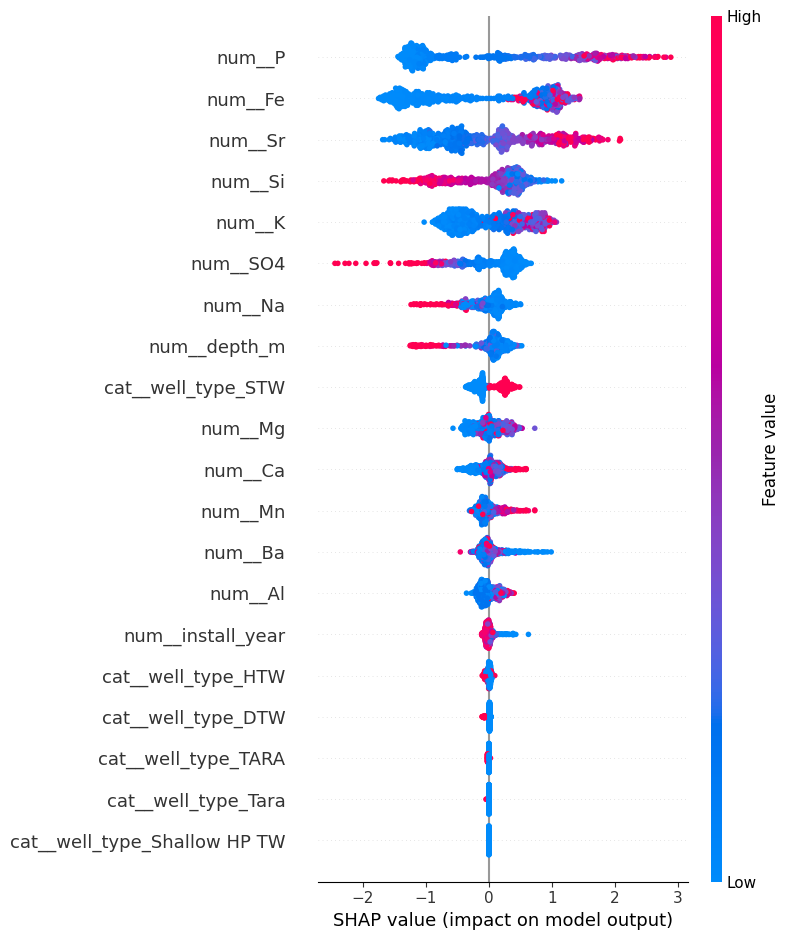

,feature,mean_abs_shap
7,num__P,1.172447
0,num__Fe,0.985480
9,num__Sr,0.760737
8,num__Si,0.491456
5,num__K,0.471100
6,num__SO4,0.417529
4,num__Na,0.221621
12,num__depth_m,0.215102
26,cat__well_type_STW,0.199955
3,num__Mg,0.180607


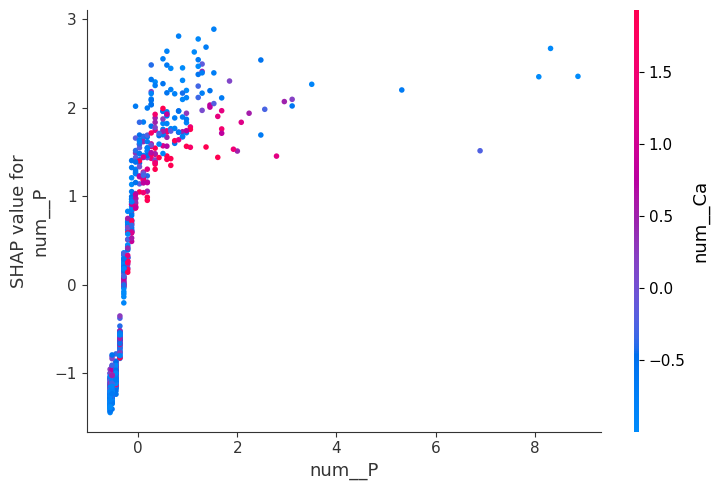

In [22]:
try:
    import shap

    prep = BEST_MODEL.named_steps["prep"]
    estimator = BEST_MODEL.named_steps["model"]
    X_test_enc = prep.transform(X_test)
    feature_names = list(prep.get_feature_names_out())

    if BEST_NAME == "MLP":
        background = shap.sample(prep.transform(X_train), 100, random_state=SEED)
        explainer = shap.KernelExplainer(estimator.predict_proba, background)
        X_test_enc = X_test_enc[:100]
        raw_shap = explainer.shap_values(X_test_enc, nsamples=100)
    else:
        explainer = shap.TreeExplainer(estimator)
        raw_shap = explainer.shap_values(X_test_enc)

    if isinstance(raw_shap, list):
        sv = np.asarray(raw_shap[1] if len(raw_shap) > 1 else raw_shap[0])
    else:
        sv = np.asarray(raw_shap)
        if sv.ndim == 3:
            sv = sv[:, :, 1]

    shap.summary_plot(sv, X_test_enc, feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()

    importance = (pd.DataFrame({"feature": feature_names, "mean_abs_shap": np.abs(sv).mean(axis=0)})
                  .sort_values("mean_abs_shap", ascending=False))
    display(importance.head(15))

    top = importance.iloc[0]["feature"]
    shap.dependence_plot(feature_names.index(top), sv, X_test_enc,
                         feature_names=feature_names, show=False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap not installed - skipped")
except Exception as exc:
    print("SHAP step failed:", exc)

## Prediction intervals - conformalized quantile regression (Scenario A, explanatory)

Calibration set: 567 wells, held out spatially from the 2250 wells used to fit the quantile regressors
Conformal correction applied to both quantiles: +0.000 log10 units

CQR interval (the recommended method): covers  91.4% of held-out wells (target 90%), median width 2.00 log10 units
Previous bootstrap+residual method (comparison only): covers  90.0%, median width 1.67 log10 units


,observed,predicted,p05,p95,width
count,717.000,717.000,717.000,717.000,717.000
mean,0.703,0.539,-0.496,1.574,2.070
std,1.115,0.456,0.264,0.780,0.725
min,-0.602,-0.274,-0.602,0.054,0.656
25%,-0.602,0.131,-0.602,0.863,1.451
50%,0.591,0.536,-0.602,1.660,2.003
75%,1.740,0.926,-0.602,2.236,2.649
max,2.936,1.539,0.218,2.877,3.479


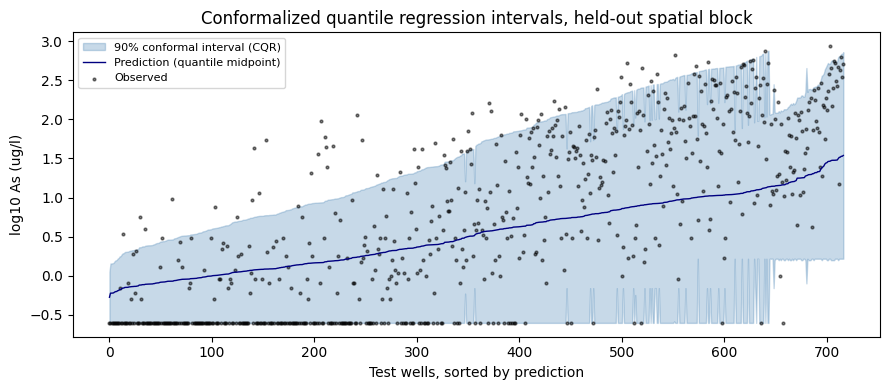

In [23]:
ALPHA = 0.10

cal_train_idx, cal_idx = spatial_split(frame_r.loc[Xr_train.index], seed=SEED + 1)


def quantile_pipe(alpha, X):
    return make_pipeline(GradientBoostingRegressor(
        loss="quantile", alpha=alpha, n_estimators=300, max_depth=3,
        learning_rate=0.05, random_state=SEED), X)


lo_pipe = quantile_pipe(ALPHA / 2, Xr_train.loc[cal_train_idx]).fit(
    Xr_train.loc[cal_train_idx], yr_train.loc[cal_train_idx])
hi_pipe = quantile_pipe(1 - ALPHA / 2, Xr_train.loc[cal_train_idx]).fit(
    Xr_train.loc[cal_train_idx], yr_train.loc[cal_train_idx])

cal_lo = lo_pipe.predict(Xr_train.loc[cal_idx])
cal_hi = hi_pipe.predict(Xr_train.loc[cal_idx])
cal_y = yr_train.loc[cal_idx].values

nonconformity = np.maximum(cal_lo - cal_y, cal_y - cal_hi)
n_cal = len(cal_y)
q_level = min(1.0, np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal)
correction = np.quantile(nonconformity, q_level)
print(f"Calibration set: {n_cal} wells, held out spatially from the {len(cal_train_idx)} wells "
      f"used to fit the quantile regressors")
print(f"Conformal correction applied to both quantiles: {correction:+.3f} log10 units")

test_lo_raw = lo_pipe.predict(Xr_test)
test_hi_raw = hi_pipe.predict(Xr_test)
cqr_lo, cqr_hi = test_lo_raw - correction, test_hi_raw + correction
cqr_pred = (test_lo_raw + test_hi_raw) / 2

cqr_coverage = ((yr_test.values >= cqr_lo) & (yr_test.values <= cqr_hi)).mean()
print(f"\nCQR interval (the recommended method): covers {cqr_coverage:6.1%} of held-out wells "
      f"(target {1 - ALPHA:.0%}), median width {np.median(cqr_hi - cqr_lo):.2f} log10 units")

N_BOOT = 30
rng = np.random.RandomState(SEED)
boot = np.zeros((N_BOOT, len(Xr_test)))
for b in range(N_BOOT):
    take = rng.choice(len(Xr_train), size=len(Xr_train), replace=True)
    model = clone(BEST_REG_MODEL)
    model.fit(Xr_train.iloc[take], yr_train.iloc[take])
    boot[b] = model.predict(Xr_test)
boot_mean = boot.mean(axis=0)
model_lo, model_hi = np.percentile(boot, [5, 95], axis=0)
oof_train = cross_val_predict(clone(BEST_REG_MODEL), Xr_train, yr_train, cv=cv_r, n_jobs=-1)
residual_lo, residual_hi = np.percentile(yr_train - oof_train, [5, 95])
old_lo, old_hi = boot_mean + residual_lo, boot_mean + residual_hi
old_coverage = ((yr_test.values >= old_lo) & (yr_test.values <= old_hi)).mean()
print(f"Previous bootstrap+residual method (comparison only): covers {old_coverage:6.1%}, "
      f"median width {np.median(old_hi - old_lo):.2f} log10 units")

intervals = pd.DataFrame(
    {"observed": yr_test.values, "predicted": cqr_pred,
     "p05": cqr_lo, "p95": cqr_hi, "width": cqr_hi - cqr_lo},
    index=Xr_test.index,
)
display(intervals.describe().round(3))

order = np.argsort(cqr_pred)
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(range(len(order)), cqr_lo[order], cqr_hi[order], alpha=0.3,
               color="steelblue", label=f"{1 - ALPHA:.0%} conformal interval (CQR)")
ax.plot(cqr_pred[order], color="navy", lw=1, label="Prediction (quantile midpoint)")
ax.scatter(range(len(order)), yr_test.values[order], s=4, color="black",
          alpha=0.5, label="Observed")
ax.set(xlabel="Test wells, sorted by prediction",
      ylabel=f"log10 {TARGET} ({UNITS.get(TARGET)})",
      title="Conformalized quantile regression intervals, held-out spatial block")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

coverage = cqr_coverage

## Multi-contaminant risk - EXPLORATORY (Scenario B, predictive/screening)

In [24]:
per_contaminant = {}
calibration_rows = []
for c in eligible.contaminant:
    target = f"{c}_exceeds"
    Xc, yc, frame_c = build_matrix(FEATURES_B, target, model_df)
    if yc.nunique() < 2 or len(yc) < MIN_VALID:
        print(f"{c}: skipped, not enough signal to model")
        continue
    pipe = make_pipeline(LogisticRegression(max_iter=2000, random_state=SEED), Xc)
    proba = cross_val_predict(pipe, Xc, yc, cv=cv_spatial(Xc, frame_c),
                              method="predict_proba", n_jobs=-1)[:, 1]
    per_contaminant[c] = pd.Series(proba, index=Xc.index)
    calibration_rows.append({
        "contaminant": c, "oof_AUC": roc_auc_score(yc, proba),
        "brier_score": brier_score_loss(yc, proba),
        "base_rate": yc.mean(),
        "brier_of_base_rate_only": yc.mean() * (1 - yc.mean()),
    })
    print(f"{c}: out-of-fold AUC {roc_auc_score(yc, proba):.3f} (base rate {yc.mean():.1%})")

calibration_table = pd.DataFrame(calibration_rows).round(3)
print("\nCalibration check on each contaminant model feeding the composite:")
display(calibration_table)
print("Brier score close to or above 'brier_of_base_rate_only' means that contaminant's predicted\n"
      "probabilities carry little more information than just guessing the base rate - the\n"
      "composite below should be trusted even less than usual for any run where that happens.\n"
      "This is a diagnostic, not a fix: no contaminant is dropped automatically from the product.")

if per_contaminant:
    risk = pd.DataFrame(per_contaminant).dropna()
    risk["composite_exploratory"] = 1 - (1 - risk[list(per_contaminant)]).prod(axis=1)

    sensitivity = []
    for c in per_contaminant:
        others = [k for k in per_contaminant if k != c]
        without = (1 - (1 - risk[others]).prod(axis=1)).mean() if others else np.nan
        sensitivity.append({"dropped": c,
                            "mean_composite": risk["composite_exploratory"].mean(),
                            "without_it": without,
                            "contribution": risk["composite_exploratory"].mean() - without})
    display(pd.DataFrame(sensitivity).sort_values("contribution", ascending=False).round(3))

    print("\nEXPLORATORY composite score distribution (not a validated index):")
    print(risk["composite_exploratory"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_string())

    risk["category_exploratory"] = pd.cut(risk["composite_exploratory"], [-0.01, 0.2, 0.5, 1.01],
                                          labels=["Low", "Moderate", "High"])
    counts = risk["category_exploratory"].value_counts()
    print("\n" + counts.to_string())
    if (counts == 0).any():
        print("\nThe fixed cut-points leave a category empty. That is what to expect when one\n"
              "common contaminant dominates the product - with iron exceeding at a high base\n"
              "rate, almost every well ends up above 0.5. Rank wells by the composite, or cut\n"
              "it at its own quantiles, rather than reading anything into these three labels.")
    print("\nAgain: this composite is exploratory. Use the relative ranking of wells, not the\n"
          "absolute score, the category label, or the 0.2/0.5 cut-points, for anything downstream.")
else:
    risk = pd.DataFrame()
    print("No contaminant could be modelled reliably - composite score skipped.")

Mn: out-of-fold AUC 0.755 (base rate 73.5%)
Fe: out-of-fold AUC 0.719 (base rate 51.2%)
As: out-of-fold AUC 0.846 (base rate 24.9%)

Calibration check on each contaminant model feeding the composite:


,contaminant,oof_AUC,brier_score,base_rate,brier_of_base_rate_only
0,Mn,0.755,0.153,0.735,0.195
1,Fe,0.719,0.214,0.512,0.250
2,As,0.846,0.128,0.249,0.187


Brier score close to or above 'brier_of_base_rate_only' means that contaminant's predicted
probabilities carry little more information than just guessing the base rate - the
composite below should be trusted even less than usual for any run where that happens.
This is a diagnostic, not a fix: no contaminant is dropped automatically from the product.


,dropped,mean_composite,without_it,contribution
0,Mn,0.87,0.590,0.280
1,Fe,0.87,0.794,0.076
2,As,0.87,0.852,0.019



EXPLORATORY composite score distribution (not a validated index):
count    3530.000
mean        0.870
std         0.198
min         0.069
10%         0.659
25%         0.859
50%         0.948
75%         0.978
90%         0.989
max         0.999

category_exploratory
High        3310
Low          137
Moderate      83

Again: this composite is exploratory. Use the relative ranking of wells, not the
absolute score, the category label, or the 0.2/0.5 cut-points, for anything downstream.


## Arsenic guideline sensitivity: 10 vs 50 ug/L (NEW)

In [25]:
AS_LIMITS_UGL = {"Bangladesh national standard (ECR 1997)": 50.0, "WHO guideline": 10.0}

as_factor = unit_factor(UNITS.get("As"), "ug/l") if "As" in df.columns else None
as_ugl_all = df["As"] * as_factor if as_factor is not None else None

if as_ugl_all is not None:
    prevalence_rows = []
    for label, limit in AS_LIMITS_UGL.items():
        exceeds = as_ugl_all > limit
        prevalence_rows.append({
            "guideline": label, "limit_ugL": limit,
            "n_measured": int(as_ugl_all.notna().sum()),
            "n_exceed": int(exceeds[as_ugl_all.notna()].sum()),
            "exceedance_rate": round(float(exceeds[as_ugl_all.notna()].mean()), 3),
        })
    print("Arsenic exceedance under each guideline, whole cleaned dataset:")
    display(pd.DataFrame(prevalence_rows))

    if TARGET == "As":
        as_test_true_ugl = 10 ** yr_test.values
        sens_rows = []
        for label, limit in AS_LIMITS_UGL.items():
            y_bin = (as_test_true_ugl > limit).astype(int)
            if 0 < y_bin.mean() < 1:
                auc = roc_auc_score(y_bin, cqr_pred)
                thr = screening_threshold(cqr_pred, y_bin.mean())
                pred_bin = (cqr_pred >= thr).astype(int)
                precision = precision_score(y_bin, pred_bin, zero_division=0)
                recall = recall_score(y_bin, pred_bin, zero_division=0)
            else:
                auc = precision = recall = np.nan
            sens_rows.append({
                "guideline": label, "limit_ugL": limit,
                "test_exceedance_rate": round(float(y_bin.mean()), 3),
                "ROC_AUC": round(float(auc), 3) if not np.isnan(auc) else np.nan,
                "Precision_at_screening_budget": round(float(precision), 3) if not np.isnan(precision) else np.nan,
                "Recall_at_screening_budget": round(float(recall), 3) if not np.isnan(recall) else np.nan,
            })
        sens_df = pd.DataFrame(sens_rows)
        print("\nSame Scenario A regression model, held-out spatial block, scored against both "
              "guidelines:")
        display(sens_df)

        n_between = int(((as_test_true_ugl > 10) & (as_test_true_ugl <= 50)).sum())
        print(f"\n{n_between} of {len(as_test_true_ugl)} held-out wells "
              f"({n_between / len(as_test_true_ugl):.1%}) sit between the two guidelines - 'safe' "
              "under the Bangladesh standard and 'exceeding' under WHO's. A well flagged under the\n"
              "stricter guideline is not automatically flagged under the more permissive one, and\n"
              "the table above is how much that choice changes who gets called 'at risk', holding\n"
              "the model fixed.")
    else:
        print(f"\n{TARGET}, not arsenic, was this run's modelled target (arsenic did not clear the\n"
              "eligibility bar in section 6), so only the descriptive exceedance-rate comparison\n"
              "above applies; a classifier-based sensitivity check would need arsenic to be the\n"
              "regression target.")
else:
    print("Arsenic column not found in this file - guideline sensitivity skipped.")

Arsenic exceedance under each guideline, whole cleaned dataset:


,guideline,limit_ugL,n_measured,n_exceed,exceedance_rate
0,Bangladesh national standard (ECR 1997),50.0,3534,881,0.249
1,WHO guideline,10.0,3534,1487,0.421



Same Scenario A regression model, held-out spatial block, scored against both guidelines:


,guideline,limit_ugL,test_exceedance_rate,ROC_AUC,Precision_at_screening_budget,Recall_at_screening_budget
0,Bangladesh national standard (ECR 1997),50.0,0.259,0.885,0.651,0.651
1,WHO guideline,10.0,0.427,0.913,0.827,0.827



120 of 717 held-out wells (16.7%) sit between the two guidelines - 'safe' under the Bangladesh standard and 'exceeding' under WHO's. A well flagged under the
stricter guideline is not automatically flagged under the more permissive one, and
the table above is how much that choice changes who gets called 'at risk', holding
the model fixed.


## Maps

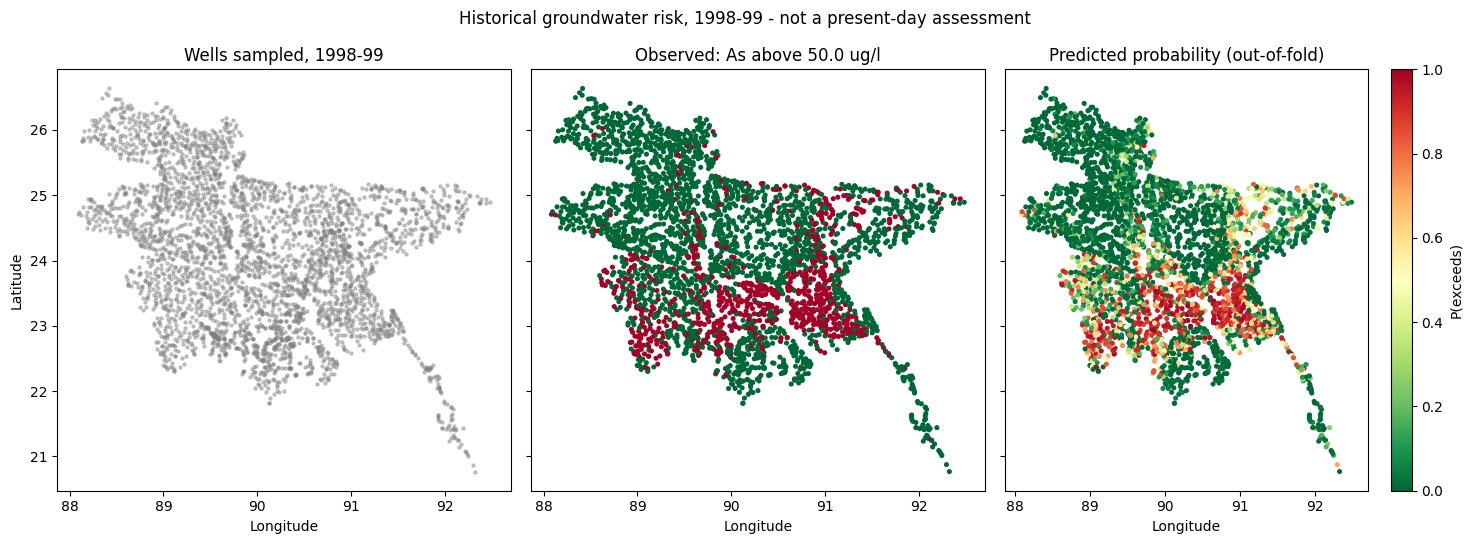

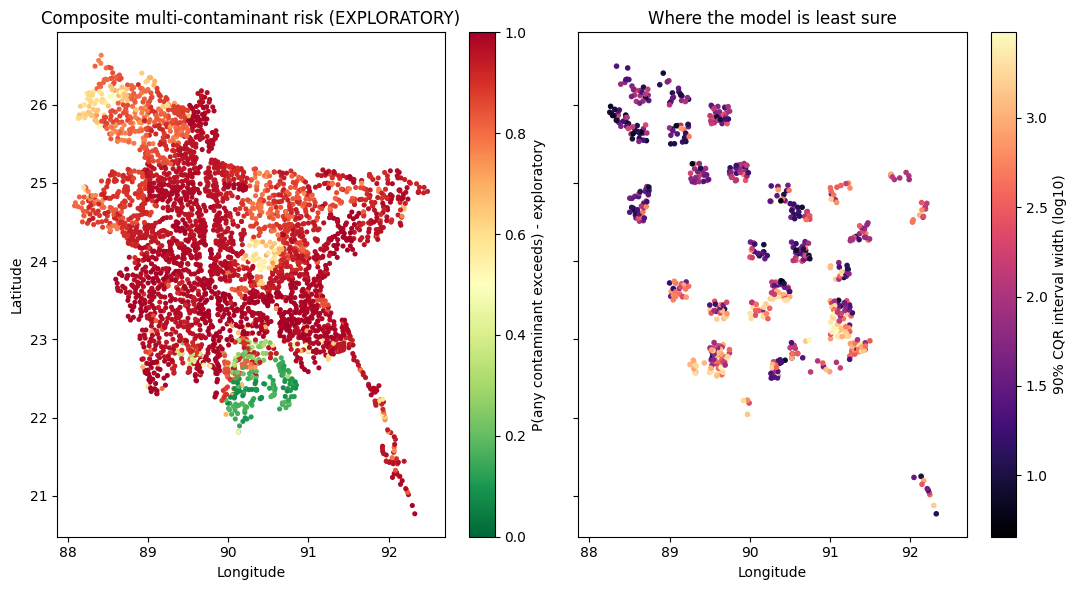

In [26]:
if has_xy:
    oof = cross_val_predict(clone(BEST_MODEL), X_all, y_all,
                            cv=cv_spatial(X_all, frame_all),
                            method="predict_proba", n_jobs=-1)[:, 1]
    oof = pd.Series(oof, index=X_all.index)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True, sharey=True)
    axes[0].scatter(frame_all["lon"], frame_all["lat"], s=5, alpha=0.4, color="grey")
    axes[0].set_title("Wells sampled, 1998-99")

    axes[1].scatter(frame_all["lon"], frame_all["lat"], c=y_all, cmap="RdYlGn_r", s=7)
    axes[1].set_title(f"Observed: {TARGET} above {TARGET_LIMIT} {TARGET_UNIT}")

    pts = axes[2].scatter(frame_all["lon"], frame_all["lat"], c=oof,
                          cmap="RdYlGn_r", s=7, vmin=0, vmax=1)
    axes[2].set_title("Predicted probability (out-of-fold)")
    fig.colorbar(pts, ax=axes[2], label="P(exceeds)")
    for ax in axes:
        ax.set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    fig.suptitle("Historical groundwater risk, 1998-99 - not a present-day assessment")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharex=True, sharey=True)
    if len(risk):
        shared = frame_all.index.intersection(risk.index)
        pts = axes[0].scatter(frame_all.loc[shared, "lon"], frame_all.loc[shared, "lat"],
                              c=risk.loc[shared, "composite_exploratory"], cmap="RdYlGn_r",
                              s=7, vmin=0, vmax=1)
        fig.colorbar(pts, ax=axes[0], label="P(any contaminant exceeds) - exploratory")
        axes[0].set_title("Composite multi-contaminant risk (EXPLORATORY)")
    else:
        axes[0].set_axis_off()

    pts = axes[1].scatter(frame_r.loc[intervals.index, "lon"], frame_r.loc[intervals.index, "lat"],
                          c=intervals["width"], cmap="magma", s=9)
    fig.colorbar(pts, ax=axes[1], label="90% CQR interval width (log10)")
    axes[1].set_title("Where the model is least sure")
    for ax in axes:
        ax.set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()
else:
    print("No coordinates - mapping skipped.")

## Results

In [27]:
print("DATA")
print(f"  {DATA_PATH}")
print(f"  {len(df)} wells after cleaning, {len(model_df)} with usable coordinates")
print(f"  Target: {TARGET} above {TARGET_LIMIT} {TARGET_UNIT} (Bangladesh ECR 1997), "
      f"exceeded at {df[CLS_TARGET].mean():.1%} of measured wells")

print("\nVALIDATION SCHEME MATTERS, AND ONE SPATIAL SPLIT IS NOT ENOUGH")
print(comparison.round(3).to_string())
real_models = comparison.index.intersection(list(MODELS))
print(f"  Random splits overstate ROC-AUC by "
      f"{comparison.loc[real_models, 'optimism'].mean():.3f} on average vs the repeated-spatial mean.")
print(f"  Across {N_REPEATS} independent spatial holdouts, {BEST_NAME}'s AUC ranged from "
      f"{spatial_summary.loc[BEST_NAME, 'min']:.3f} to {spatial_summary.loc[BEST_NAME, 'max']:.3f} "
      f"depending on which blocks were withheld.")
print("  Quote the repeated-spatial mean +/- std for a new area, not a single spatial split.")

print("\nCLASSIFICATION, repeated spatial holdouts (mean +/- std ROC-AUC)")
print(spatial_summary.round(3).to_string())

print("\nREGRESSION, repeated spatial holdouts")
print(reg_summary.round(3).to_string())

if "importance" in globals():
    print("\nTOP FEATURES (mean |SHAP|), Scenario A")
    print(importance.head(10).round(4).to_string(index=False))

print("\nUNCERTAINTY (conformalized quantile regression, replacing the old bootstrap+residual method)")
print(f"  90% CQR intervals cover {cqr_coverage:.1%} of held-out observations (target 90%)")
print(f"  Previous bootstrap+residual method covered {old_coverage:.1%} on the same wells")

if len(risk):
    print("\nMULTI-CONTAMINANT RISK - EXPLORATORY, not independently validated")
    print(risk["category_exploratory"].value_counts().to_string())
    print("  Calibration table in section 17 shows which contaminant models are least trustworthy.")

if TARGET == "As" and "sens_df" in globals():
    print("\nARSENIC GUIDELINE SENSITIVITY (10 vs 50 ug/L), same model, held-out block")
    print(sens_df.to_string(index=False))

print("\nTAKEAWAY")
print("  Random-split validation flatters models on spatially autocorrelated groundwater data,")
print("  and a single spatial split is itself not enough - repeated spatial holdouts show how much")
print("  that number moves depending on which areas are withheld. Reported here is the repeated-")
print("  spatial mean, with SHAP attributions, a coverage-checked conformal interval, an explicitly")
print("  exploratory multi-contaminant score, and a sensitivity check on the arsenic guideline")
print("  itself, as a historical baseline for the 1998-99 survey.")

DATA
  /kaggle/input/datasets/mdnahidurrahmankh/bangladesh-national-groundwater-hydrochemical/NationalSurveyData.csv
  3534 wells after cleaning, 3534 with usable coordinates
  Target: As above 50.0 ug/l (Bangladesh ECR 1997), exceeded at 24.9% of measured wells

VALIDATION SCHEME MATTERS, AND ONE SPATIAL SPLIT IS NOT ENOUGH
split               random  spatial  spatial_repeated_mean  spatial_repeated_std  optimism
model                                                                                     
CatBoost             0.955    0.953                  0.953                 0.009     0.002
XGBoost              0.948    0.950                  0.953                 0.008    -0.005
LightGBM             0.953    0.952                  0.950                 0.009     0.003
RandomForest         0.944    0.947                  0.950                 0.009    -0.006
MLP                  0.903    0.906                  0.893                 0.039     0.010
Dummy                0.500    0.500 